## Data Loading

This is a notebook implementing some of the code from ```lab4-5.py```. The only dependencies are pandas, numpy, and matplotlib. You'll also need ipykernel if you want to run this notebook using a virtual environment (which I did).

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('DisasterDeclarationsSummaries.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70422 entries, 0 to 70421
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   femaDeclarationString     70422 non-null  str  
 1   disasterNumber            70422 non-null  int64
 2   state                     70422 non-null  str  
 3   declarationType           70422 non-null  str  
 4   declarationDate           70422 non-null  str  
 5   fyDeclared                70422 non-null  int64
 6   incidentType              70422 non-null  str  
 7   declarationTitle          70422 non-null  str  
 8   ihProgramDeclared         70422 non-null  int64
 9   iaProgramDeclared         70422 non-null  int64
 10  paProgramDeclared         70422 non-null  int64
 11  hmProgramDeclared         70422 non-null  int64
 12  incidentBeginDate         70422 non-null  str  
 13  incidentEndDate           69800 non-null  str  
 14  disasterCloseoutDate      52685 non-null  str  
 

In [3]:
df = df.drop(columns=["lastRefresh", "hash", "id"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70422 entries, 0 to 70421
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   femaDeclarationString     70422 non-null  str  
 1   disasterNumber            70422 non-null  int64
 2   state                     70422 non-null  str  
 3   declarationType           70422 non-null  str  
 4   declarationDate           70422 non-null  str  
 5   fyDeclared                70422 non-null  int64
 6   incidentType              70422 non-null  str  
 7   declarationTitle          70422 non-null  str  
 8   ihProgramDeclared         70422 non-null  int64
 9   iaProgramDeclared         70422 non-null  int64
 10  paProgramDeclared         70422 non-null  int64
 11  hmProgramDeclared         70422 non-null  int64
 12  incidentBeginDate         70422 non-null  str  
 13  incidentEndDate           69800 non-null  str  
 14  disasterCloseoutDate      52685 non-null  str  
 

## Sample Queries

In [4]:
(
    df
    .groupby("declarationType")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

,declarationType,count
0,DR,46688
1,EM,21572
2,FM,2162


In [ ]:
(
    df
    .query("declarationType == 'DR'")
    .groupby(["state"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
    .head(11)
)

,state,count
0,TX,3087
1,KY,2565
2,MO,2100
3,OK,1791
4,VA,1759
5,IA,1691
6,FL,1629
7,KS,1586
8,TN,1556
9,MS,1535


In [6]:
(
    df
    .query("declarationType == 'DR'")
    .groupby(["declarationTitle"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
    .head(10)
)

,declarationTitle,count
0,COVID-19 PANDEMIC,4165
1,SEVERE STORMS AND FLOODING,3883
2,SEVERE STORMS & FLOODING,3381
3,"SEVERE STORMS, TORNADOES, AND FLOODING",2049
4,SEVERE WINTER STORM,1424
5,FLOODING,1317
6,SEVERE WINTER STORMS,1077
7,"SEVERE STORMS, TORNADOES, STRAIGHT-LINE WINDS,...",1072
8,"SEVERE STORMS, TORNADOES & FLOODING",971
9,"SEVERE STORMS, STRAIGHT-LINE WINDS, TORNADOES,...",868


In [7]:
(
    df
    .query("declarationType == 'DR'")
    .groupby(["incidentType"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

,incidentType,count
0,Severe Storm,17951
1,Flood,10878
2,Hurricane,5993
3,Biological,4165
4,Severe Ice Storm,1793
5,Snowstorm,1572
6,Tornado,1518
7,Fire,1076
8,Winter Storm,361
9,Tropical Storm,330


In [10]:
excluded_incidents = [
    "Biological",
    "Fishing Losses",
    "Other",
    "Toxic Substances",
    "Human Cause",
    "Terrorist"
]

(
    df
    .query("declarationType == 'DR'"
           "and incidentType not in @excluded_incidents")
    .groupby(["incidentType"])    
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

,incidentType,count
0,Severe Storm,17951
1,Flood,10878
2,Hurricane,5993
3,Severe Ice Storm,1793
4,Snowstorm,1572
5,Tornado,1518
6,Fire,1076
7,Winter Storm,361
8,Tropical Storm,330
9,Freezing,301


In [11]:
(
    df
    .query("declarationType == 'DR'"
           "and incidentType not in @excluded_incidents")

    # .groupby(["designatedArea","state"])

    .assign(
            designatedArea_state=lambda x:
                x["designatedArea"].astype(str) + ", " + x["state"].astype(str)
        )
    .groupby(["designatedArea_state"])
    
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

,designatedArea_state,count
0,"Owsley (County), KY",41
1,"Breathitt (County), KY",39
2,"Lawrence (County), KY",39
3,"Perry (County), KY",39
4,"Magoffin (County), KY",39
...,...,...
3490,"Aleutians West (Census Area), AK",1
3491,"Aleutians East (Borough), AK",1
3492,"Ysleta del Sur Pueblo (Indian Reservation), TX",1
3493,"Aleutian Islands (Census Subarea), AK",1


In [12]:
(
    df
    .query("declarationType == 'DR'"
           "and incidentType not in @excluded_incidents")["designatedArea"]
    .str.lower()
    .str.split()
    .explode()
    .value_counts()
    .head(50)
)

designatedArea
(county)               38074
(parish)                1425
(municipio)             1214
st.                      532
jefferson                426
washington               405
franklin                 353
jackson                  351
lincoln                  321
reservation              299
san                      298
(county)(in              298
clay                     283
madison                  280
indian                   276
montgomery               247
marion                   239
monroe                   236
union                    215
wayne                    211
carroll                  210
lake                     202
greene                   198
(p)msa                   187
polk                     185
grant                    184
statewide                183
lawrence                 179
marshall                 178
(county-equivalent)      176
perry                    175
lee                      174
pike                     173
calhoun                  164

In [13]:
included_areas = "county|parish|municipio"

(
    df
    .query(
        "declarationType == 'DR' "
        "and incidentType not in @excluded_incidents "
        "and designatedArea.str.contains(@included_areas, case=False, na=False)",
        )
    [["designatedArea", "state"]]
    .groupby(["designatedArea", "state"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

,designatedArea,state,count
0,Owsley (County),KY,41
1,Magoffin (County),KY,39
2,Breathitt (County),KY,39
3,Perry (County),KY,39
4,Lawrence (County),KY,39
...,...,...,...
3166,Caribou (County),ID,1
3167,Canyon (County),ID,1
3168,Carbon (County),UT,1
3169,Carbon (County),WY,1


In [14]:
(
    df
    .query(
        "declarationType == 'DR' "
        "and incidentType not in @excluded_incidents "
        "and designatedArea.str.contains(@included_areas, case=False, na=False)",
        )
    .groupby(["fyDeclared"])
    .size()
)

fyDeclared
1959       1
1965     539
1966     121
1967     193
1968     149
        ... 
2022     702
2023     872
2024    1195
2025     827
2026     644
Length: 63, dtype: int64

In [15]:
(
    df
    .query(
        "declarationType == 'DR' "
        "and incidentType not in @excluded_incidents "
        "and designatedArea.str.contains(@included_areas, case=False, na=False)",
        )
    ["fyDeclared"].value_counts().sort_index()
)


fyDeclared
1959       1
1965     539
1966     121
1967     193
1968     149
        ... 
2022     702
2023     872
2024    1195
2025     827
2026     644
Name: count, Length: 63, dtype: int64

## Cleaning

In [16]:
df_clean = (
    df
    .query(
        "declarationType == 'DR' "
        "and incidentType not in @excluded_incidents "
        "and designatedArea.str.contains(@included_areas, case=False, na=False)"
        "and fyDeclared != 2026 ",
        engine="python"
    )
    .assign(
        year_month=lambda x: pd.to_datetime(x["declarationDate"]).dt.strftime("%Y-%m"),
        year=lambda x: pd.to_datetime(x["declarationDate"]).dt.year,
        month=lambda x: pd.to_datetime(x["declarationDate"]).dt.month
    )
)

df_clean["fyDeclared"].value_counts().sort_index()

df_clean["year"].value_counts().sort_index()

df_clean["year"].value_counts().reset_index(name="count").sort_index(ascending=True)

df_clean["month"].value_counts().reset_index(name="count").sort_index()

,month,count
0,9,5064
1,5,4793
2,7,4153
3,4,4090
4,6,3973
5,1,3547
6,3,3511
7,2,3246
8,8,3111
9,10,2407


## Plots

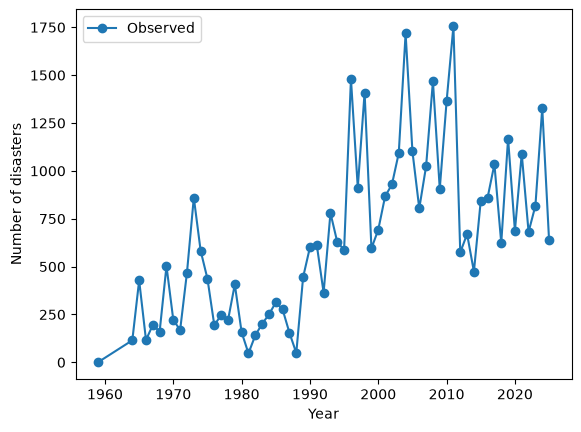

In [17]:
annual = (
    df_clean["year"]
    .value_counts()
    .sort_index()
    .rename_axis("year")
    .reset_index(name="disasterDeclarations")
)

annual.plot(
    x="year",
    y="disasterDeclarations",
    # kind="scatter",
    kind="line",
    marker="o",
    # figsize=(10, 5),
    label="Observed",
    xlabel="Year",
    ylabel="Number of disasters"
).legend(loc="upper left")

## Prediction

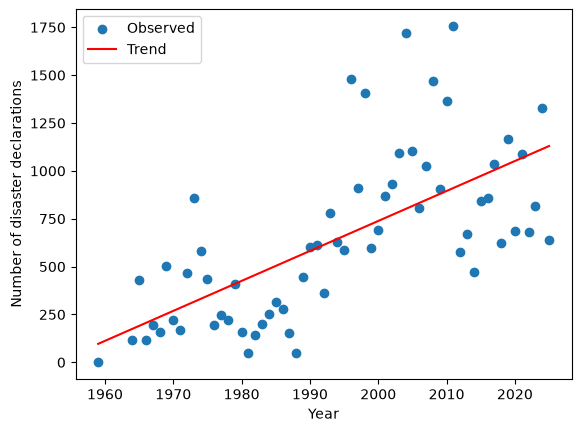

In [20]:
x = annual["year"]
y = annual["disasterDeclarations"]

m = ((x - x.mean()) * (y - y.mean())).sum() / ((x - x.mean())**2).sum()
b = y.mean() - m * x.mean()

plt.cla()

plt.scatter(x, y, label="Observed")
plt.plot(x, m*x + b, label="Trend", color="red")

plt.xlabel("Year")
plt.ylabel("Number of disaster declarations")
plt.legend(loc="upper left")
plt.show()